# 🎵 Music Prediction & Recommendation System

This notebook builds a **content-based music recommendation system** using the Spotify dataset.
It covers:
1. **Data Loading & Exploration** – understand the dataset
2. **Data Cleaning & Feature Engineering** – prepare features
3. **Exploratory Data Analysis (EDA)** – visualise trends
4. **Genre-level clustering** – group genres with KMeans
5. **Song-level kNN model** – find nearest neighbours in feature space
6. **Recommendation engine** – get top-N song suggestions
7. **Model persistence** – save & reload the model

---

## 1. Imports & Configuration

In [20]:
import os
import ast
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)
%matplotlib inline

print('All libraries imported successfully!')


All libraries imported successfully!


## 2. Data Loading

In [21]:
DATA_DIR = '.'

df        = pd.read_csv(f'{DATA_DIR}/data.csv')
by_artist = pd.read_csv(f'{DATA_DIR}/data_by_artist.csv')
by_genre  = pd.read_csv(f'{DATA_DIR}/data_by_genres.csv')
by_year   = pd.read_csv(f'{DATA_DIR}/data_by_year.csv')
w_genres  = pd.read_csv(f'{DATA_DIR}/data_w_genres.csv')

print('Dataset shapes:')
for name, d in [('data', df), ('by_artist', by_artist), ('by_genre', by_genre),
                ('by_year', by_year), ('w_genres', w_genres)]:
    print(f'  {name:12s}  {d.shape}')

df.head()


Dataset shapes:
  data          (170653, 19)
  by_artist     (28680, 15)
  by_genre      (2973, 14)
  by_year       (100, 14)
  w_genres      (28680, 16)


,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo
0,0.0594,1921,0.982,"['Sergei Rachmaninoff', 'James Levine', 'Berli...",0.279,831667,0.211,0,4BJqT0PrAfrxzMOxytFOIz,0.878000,10,0.665,-20.096,1,"Piano Concerto No. 3 in D Minor, Op. 30: III. ...",4,1921,0.0366,80.954
1,0.9630,1921,0.732,['Dennis Day'],0.819,180533,0.341,0,7xPhfUan2yNtyFG0cUWkt8,0.000000,7,0.160,-12.441,1,Clancy Lowered the Boom,5,1921,0.4150,60.936
2,0.0394,1921,0.961,['KHP Kridhamardawa Karaton Ngayogyakarta Hadi...,0.328,500062,0.166,0,1o6I8BglA6ylDMrIELygv1,0.913000,3,0.101,-14.850,1,Gati Bali,5,1921,0.0339,110.339
3,0.1650,1921,0.967,['Frank Parker'],0.275,210000,0.309,0,3ftBPsC5vPBKxYSee08FDH,0.000028,5,0.381,-9.316,1,Danny Boy,3,1921,0.0354,100.109
4,0.2530,1921,0.957,['Phil Regan'],0.418,166693,0.193,0,4d6HGyGT8e121BsdKmw9v6,0.000002,3,0.229,-10.096,1,When Irish Eyes Are Smiling,2,1921,0.0380,101.665


## 3. Data Quality Check

In [22]:
df.info()
print('\nMissing values:\n', df.isna().sum()[df.isna().sum() > 0])
print('Duplicate ids:',              df.duplicated(subset='id').sum())
print('Duplicate (name, artists):',  df.duplicated(subset=['name', 'artists']).sum())
df.describe().T


<class 'pandas.DataFrame'>
RangeIndex: 170653 entries, 0 to 170652
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   valence           170653 non-null  float64
 1   year              170653 non-null  int64  
 2   acousticness      170653 non-null  float64
 3   artists           170653 non-null  str    
 4   danceability      170653 non-null  float64
 5   duration_ms       170653 non-null  int64  
 6   energy            170653 non-null  float64
 7   explicit          170653 non-null  int64  
 8   id                170653 non-null  str    
 9   instrumentalness  170653 non-null  float64
 10  key               170653 non-null  int64  
 11  liveness          170653 non-null  float64
 12  loudness          170653 non-null  float64
 13  mode              170653 non-null  int64  
 14  name              170653 non-null  str    
 15  popularity        170653 non-null  int64  
 16  release_date      170653 non-nu

,count,mean,std,min,25%,50%,75%,max
valence,170653.0,0.528587,0.263171,0.0,0.3170,0.540000,0.7470,1.000
year,170653.0,1976.787241,25.917853,1921.0,1956.0000,1977.000000,1999.0000,2020.000
acousticness,170653.0,0.502115,0.376032,0.0,0.1020,0.516000,0.8930,0.996
danceability,170653.0,0.537396,0.176138,0.0,0.4150,0.548000,0.6680,0.988
duration_ms,170653.0,230948.310666,126118.414668,5108.0,169827.0000,207467.000000,262400.0000,5403500.000
energy,170653.0,0.482389,0.267646,0.0,0.2550,0.471000,0.7030,1.000
explicit,170653.0,0.084575,0.278249,0.0,0.0000,0.000000,0.0000,1.000
instrumentalness,170653.0,0.167010,0.313475,0.0,0.0000,0.000216,0.1020,1.000
key,170653.0,5.199844,3.515094,0.0,2.0000,5.000000,8.0000,11.000
liveness,170653.0,0.205839,0.174805,0.0,0.0988,0.136000,0.2610,1.000


## 4. Data Cleaning & Feature Engineering

In [23]:
# Parse artists list stored as string -> readable label
df['artists_clean']  = df['artists'].apply(lambda x: ', '.join(ast.literal_eval(x)))
df['primary_artist'] = df['artists'].apply(lambda x: ast.literal_eval(x)[0])

# Remove duplicates – keep most popular version of each track
before = len(df)
df = (
    df.sort_values('popularity', ascending=False)
      .drop_duplicates(subset=['name', 'artists_clean'])
      .reset_index(drop=True)
)
print(f'Removed {before - len(df)} duplicate tracks -> {len(df)} remain')

# Drop very short clips (< 30 s)
df = df[df['duration_ms'] > 30_000].reset_index(drop=True)
print('Final shape:', df.shape)


Removed 12968 duplicate tracks -> 157685 remain
Final shape: (157519, 21)


## 5. Exploratory Data Analysis

### 5.1 Audio Feature Distributions

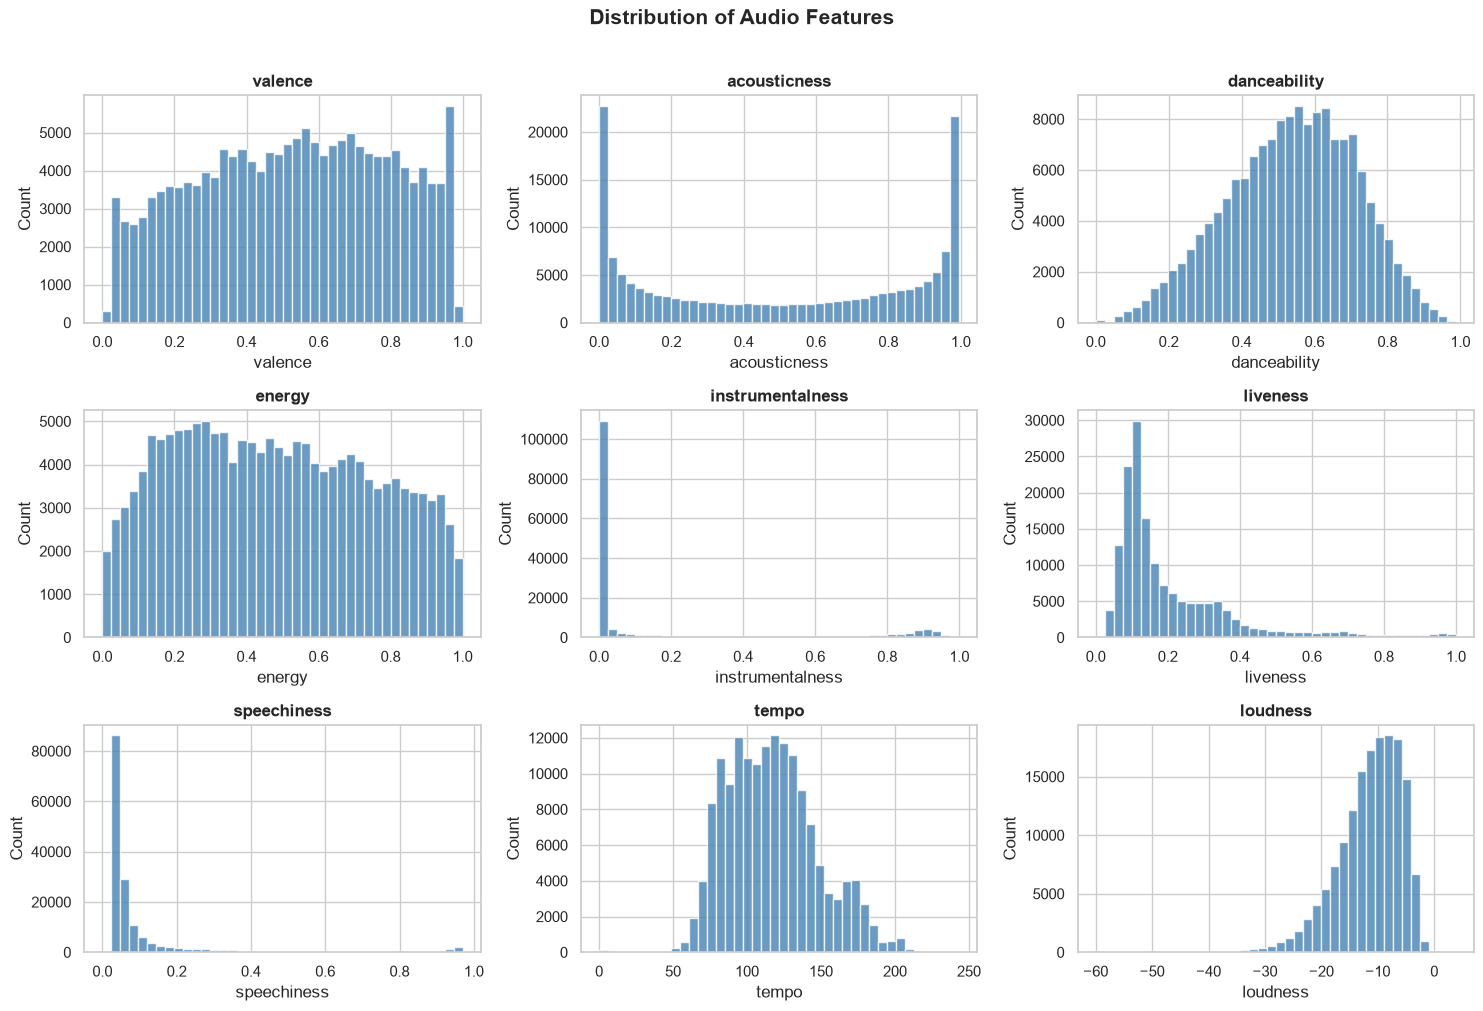

In [24]:
audio_features = [
    'valence', 'acousticness', 'danceability', 'energy',
    'instrumentalness', 'liveness', 'speechiness', 'tempo', 'loudness'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, feat in zip(axes.flatten(), audio_features):
    ax.hist(df[feat].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Count')
plt.suptitle('Distribution of Audio Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 5.2 Trends Over Time

In [25]:
trend_features = ['valence', 'energy', 'danceability', 'acousticness']
year_mean = by_year.groupby('year')[trend_features].mean().reset_index()

fig = px.line(
    year_mean.melt(id_vars='year', value_vars=trend_features,
                   var_name='Feature', value_name='Average'),
    x='year', y='Average', color='Feature',
    title='Average Audio Feature Trends Over Time',
    labels={'year': 'Year', 'Average': 'Mean Value'}
)
fig.show()


### 5.3 Correlation Heatmap

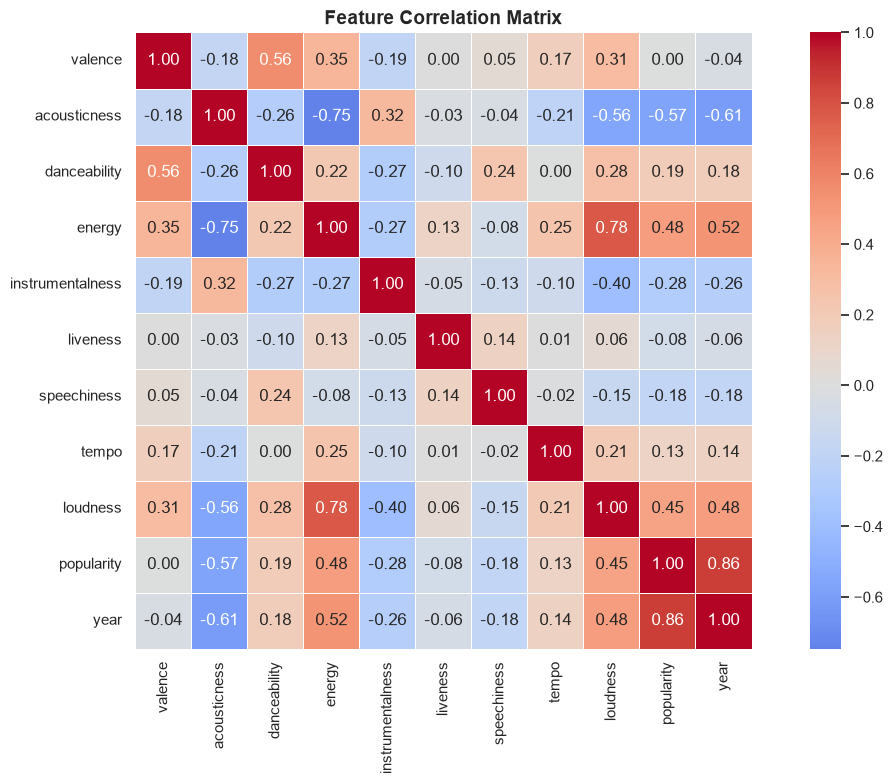

In [26]:
numeric_cols = df[audio_features + ['popularity', 'year']]
corr = numeric_cols.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, square=True, linewidths=0.5
)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 5.4 Top 15 Most Popular Songs

In [27]:
top15 = df.nlargest(15, 'popularity')[['name', 'artists_clean', 'year', 'popularity']]

fig = px.bar(
    top15, x='popularity', y='name',
    orientation='h',
    hover_data=['artists_clean', 'year'],
    title='Top 15 Most Popular Songs',
    labels={'name': 'Song', 'popularity': 'Popularity Score'}
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()


## 6. Genre-Level Clustering (KMeans)

We cluster similar genres using KMeans on audio features from `data_by_genres.csv`.

In [28]:
GENRE_FEATURES = [
    'acousticness', 'danceability', 'energy', 'instrumentalness',
    'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'popularity'
]

genre_clean = by_genre.dropna(subset=GENRE_FEATURES).copy()

genre_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=10, n_init=20, random_state=42))
])
genre_pipeline.fit(genre_clean[GENRE_FEATURES])
genre_clean['cluster'] = genre_pipeline.named_steps['kmeans'].labels_

print('Genre cluster distribution:')
print(genre_clean['cluster'].value_counts().sort_index())


Genre cluster distribution:
cluster
0     62
1    339
2    421
3    320
4    445
5    579
6     21
7    331
8    236
9    219
Name: count, dtype: int64


In [29]:
scaler_g = StandardScaler()
X_genre_scaled = scaler_g.fit_transform(genre_clean[GENRE_FEATURES])

pca_g = PCA(n_components=2, random_state=42)
coords_g = pca_g.fit_transform(X_genre_scaled)

genre_viz = pd.DataFrame(coords_g, columns=['PC1', 'PC2'])
genre_viz['cluster'] = genre_clean['cluster'].values
genre_viz['genres']  = genre_clean['genres'].values

fig = px.scatter(
    genre_viz, x='PC1', y='PC2',
    color=genre_viz['cluster'].astype(str),
    hover_data=['genres'],
    title='Genre Clusters (PCA 2D projection)',
    labels={'color': 'Cluster'}
)
fig.show()


### 6.1 Elbow Method – Optimal Number of Clusters

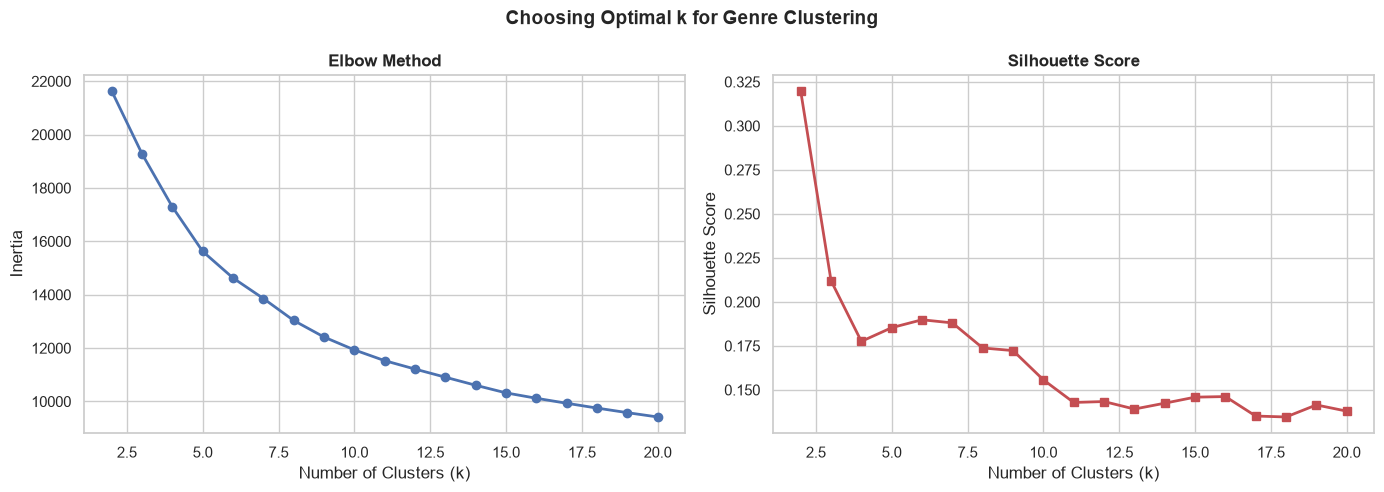

Best k by silhouette score: 2 (score=0.3198)


In [30]:
inertias = []
sil_scores = []
K_range = range(2, 21)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_genre_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_genre_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(K_range), inertias, 'bo-', linewidth=2)
ax1.set_title('Elbow Method', fontweight='bold')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')

ax2.plot(list(K_range), sil_scores, 'rs-', linewidth=2)
ax2.set_title('Silhouette Score', fontweight='bold')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')

plt.suptitle('Choosing Optimal k for Genre Clustering', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

best_k = list(K_range)[sil_scores.index(max(sil_scores))]
print(f'Best k by silhouette score: {best_k} (score={max(sil_scores):.4f})')


## 7. Song-Level Feature Matrix & Scaling

In [31]:
SONG_FEATURES = [
    'valence', 'acousticness', 'danceability', 'duration_ms',
    'energy', 'explicit', 'instrumentalness', 'key',
    'liveness', 'loudness', 'mode', 'popularity',
    'speechiness', 'tempo'
]

df_model = df.dropna(subset=SONG_FEATURES).copy().reset_index(drop=True)
print(f'Modelling subset: {len(df_model)} songs')

scaler = StandardScaler()
X = scaler.fit_transform(df_model[SONG_FEATURES])
print(f'Feature matrix shape: {X.shape}')


Modelling subset: 157519 songs
Feature matrix shape: (157519, 14)


## 8. k-Nearest-Neighbours Model

Brute-force cosine similarity avoids building a 157k x 157k matrix (~200 GB RAM).

In [32]:
nn_model = NearestNeighbors(
    n_neighbors=21,
    metric='cosine',
    algorithm='brute',
    n_jobs=-1
)
nn_model.fit(X)
print('kNN model trained!')
nn_model


kNN model trained!


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",21
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'brute'
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",-1
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
Name,Type,Value
effective_metric_ effective_metric_: strMetric used to compute distances to neighbors.,str,'cosine'
effective_metric_params_ effective_metric_params_: dictParameters for the metric used to compute distances to neighbors.,dict,{}


## 9. Recommendation Engine

In [33]:
def find_song(name, artist=None):
    m = df_model[df_model['name'].str.lower() == name.lower()]
    if artist:
        m = m[m['artists_clean'].str.lower().str.contains(artist.lower())]
    if m.empty:
        raise ValueError(f"'{name}' not found.")
    return m['popularity'].idxmax()


def recommend(name, artist=None, n=10):
    idx = find_song(name, artist)
    dist, ind = nn_model.kneighbors(X[idx].reshape(1, -1), n_neighbors=n + 1)
    recs = df_model.iloc[ind[0][1:]][['name', 'artists_clean', 'year', 'popularity']].copy()
    recs['similarity'] = (1 - dist[0][1:]).round(3)
    seed = df_model.loc[idx]
    print(f"Because you like: {seed['name']} - {seed['artists_clean']} ({seed['year']})\n")
    return recs.reset_index(drop=True)


def recommend_multi(songs, n=10):
    seed_idxs = []
    for entry in songs:
        if isinstance(entry, (list, tuple)):
            nm = entry[0]
            ar = entry[1] if len(entry) > 1 else None
        else:
            nm, ar = entry, None
        seed_idxs.append(find_song(nm, ar))
    query_vec = X[seed_idxs].mean(axis=0).reshape(1, -1)
    dist, ind = nn_model.kneighbors(query_vec, n_neighbors=n + len(seed_idxs))
    recs_all = [(i, d) for i, d in zip(ind[0], dist[0]) if i not in seed_idxs][:n]
    idxs = [r[0] for r in recs_all]
    sims = [round(1 - r[1], 3) for r in recs_all]
    recs = df_model.iloc[idxs][['name', 'artists_clean', 'year', 'popularity']].copy()
    recs['avg_similarity'] = sims
    seeds_str = ', '.join(
        f"{df_model.loc[i, 'name']} ({df_model.loc[i, 'artists_clean']})"
        for i in seed_idxs
    )
    print(f"Based on your taste: {seeds_str}\n")
    return recs.reset_index(drop=True)


print('Recommendation functions ready!')


Recommendation functions ready!


### 9.1 Single Seed Song

In [34]:
recommend('Blinding Lights', n=10)

Because you like: Blinding Lights - The Weeknd (2020)



,name,artists_clean,year,popularity,similarity
0,Secrets,OneRepublic,2009,76,0.980
1,They Don't Know About Us,One Direction,2012,79,0.976
2,Forever After All,Luke Combs,2020,86,0.970
3,Thunder,Imagine Dragons,2017,84,0.969
4,Fireflies,Owl City,2009,79,0.968
5,Getaway Car,Taylor Swift,2017,71,0.966
6,Black And White,Niall Horan,2020,80,0.963
7,Magic Shop,BTS,2018,72,0.958
8,Paramar,Los Prisioneros,1984,59,0.956
9,Versace on the Floor,Bruno Mars,2016,74,0.955


### 9.2 Single Seed with Artist Filter

In [35]:
recommend('Shape of You', artist='Ed Sheeran', n=10)

Because you like: Shape of You - Ed Sheeran (2017)



,name,artists_clean,year,popularity,similarity
0,On the Low,Burna Boy,2019,73,0.977
1,El Efecto,"Rauw Alejandro, Chencho Corleone",2019,81,0.973
2,Because Of You,Ne-Yo,2007,76,0.972
3,Nunca Es Suficiente,"Los Ángeles Azules, Natalia Lafourcade",2018,66,0.962
4,Beast Of Burden - Remastered,The Rolling Stones,1978,74,0.957
5,Besar Tu Piel,Rayito Colombiano,1997,63,0.949
6,Baby I'm Yours,"Breakbot, Irfane",2012,70,0.949
7,Métele Sazón,"Luny Tunes, Noriega, Tego Calderon",2003,60,0.948
8,How Long,Charlie Puth,2018,73,0.943
9,El Buho,Luis R Conriquez,2019,67,0.941


### 9.3 Multi-Seed Recommendation

In [36]:
recommend_multi(
    [('Blinding Lights', 'The Weeknd'),
     ('Shape of You',    'Ed Sheeran'),
     ('Dance Monkey',    'Tones and I')],
    n=10
)


Based on your taste: Blinding Lights (The Weeknd), Shape of You (Ed Sheeran), Dance Monkey (Tones And I)



,name,artists_clean,year,popularity,avg_similarity
0,Prisoner (feat. Dua Lipa),"Miley Cyrus, Dua Lipa",2020,85,0.931
1,Dead To Me,Kali Uchis,2018,78,0.928
2,Drag Me Down,One Direction,2015,81,0.918
3,Level of Concern,Twenty One Pilots,2020,77,0.917
4,Symphony (feat. Zara Larsson),"Clean Bandit, Zara Larsson",2017,76,0.917
5,Wait a Minute!,WILLOW,2015,83,0.915
6,Lamento Boliviano,Los Enanitos Verdes,1994,75,0.914
7,Dynamite,BTS,2020,97,0.913
8,Stay,"Zedd, Alessia Cara",2017,77,0.911
9,Odio (feat. Drake),"Romeo Santos, Drake",2014,72,0.909


## 10. t-SNE Visualisation of Song Feature Space

In [38]:
SAMPLE_SIZE = 5000
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X), size=min(SAMPLE_SIZE, len(X)), replace=False)

X_sample    = X[sample_idx]
pop_sample  = df_model.iloc[sample_idx]['popularity'].values
name_sample = df_model.iloc[sample_idx]['name'].values

print(f'Running t-SNE on {len(X_sample)} songs ...')
tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto',
            init='pca', random_state=42, n_iter=1000)
coords_tsne = tsne.fit_transform(X_sample)

tsne_df = pd.DataFrame(coords_tsne, columns=['x', 'y'])
tsne_df['popularity'] = pop_sample
tsne_df['name']       = name_sample

fig = px.scatter(
    tsne_df, x='x', y='y',
    color='popularity',
    hover_data=['name'],
    color_continuous_scale='Viridis',
    title=f't-SNE of {len(X_sample)} Songs (coloured by Popularity)',
    opacity=0.6, width=900, height=650
)
fig.show()


Running t-SNE on 5000 songs ...


TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'

## 11. Interactive Song Search

In [ ]:
def search_songs(query, max_results=20):
    """Search for songs by partial title."""
    mask = df_model['name'].str.contains(query, case=False, na=False)
    results = (
        df_model[mask][['name', 'artists_clean', 'year', 'popularity']]
          .sort_values('popularity', ascending=False)
          .head(max_results)
          .reset_index(drop=True)
    )
    print(f"Found {len(results)} match(es) for '{query}'")
    return results


search_songs('Love', max_results=10)


## 12. Save & Reload the Model

In [ ]:
MODEL_DIR = 'models'
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(nn_model, f'{MODEL_DIR}/knn_recommender.pkl')
joblib.dump(scaler,   f'{MODEL_DIR}/scaler.pkl')
df_model.to_parquet(f'{MODEL_DIR}/df_model.parquet', index=False)
with open(f'{MODEL_DIR}/feature_matrix.pkl', 'wb') as f:
    pickle.dump(X, f)

print(f"Model artifacts saved to '{MODEL_DIR}/'")
print('  - knn_recommender.pkl')
print('  - scaler.pkl')
print('  - df_model.parquet')
print('  - feature_matrix.pkl')


In [ ]:
# ---------- Reload demo ----------
nn_model_loaded = joblib.load(f'{MODEL_DIR}/knn_recommender.pkl')
scaler_loaded   = joblib.load(f'{MODEL_DIR}/scaler.pkl')
df_model_loaded = pd.read_parquet(f'{MODEL_DIR}/df_model.parquet')
with open(f'{MODEL_DIR}/feature_matrix.pkl', 'rb') as f:
    X_loaded = pickle.load(f)

print('Model reloaded successfully!')
print(f'  df_model shape : {df_model_loaded.shape}')
print(f'  X shape        : {X_loaded.shape}')


## 13. Summary & Next Steps

### What was built
| Step | Technique |
|------|-----------|
| Data cleaning | Duplicate removal, short-clip filtering |
| Genre clustering | `StandardScaler` + `KMeans` + PCA visualisation |
| Song-level model | `StandardScaler` + `NearestNeighbors` (cosine, brute-force) |
| Recommendation | Single-seed & multi-seed query |
| Model persistence | `joblib` + `parquet` |

### Possible improvements
- **Hybrid filtering**: combine content similarity with collaborative filtering.
- **Deep embeddings**: autoencoder for richer audio feature representations.
- **Live Spotify API**: enrich dataset with real-time popularity and audio analysis.
- **User interface**: Flask / FastAPI endpoint or Streamlit app.
- **Evaluation**: A/B test recommendations against a held-out user-rating dataset.